# 📈 Stock Trading Strategy Simulator

## 🎯 Objective
To analyze stock market data and evaluate trading strategies using historical price data.


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [16]:
data = yf.download("TCS.NS", start="2018-01-01", end="2024-01-01")
data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
Date,,,,,
2018-01-01,1083.771240,1103.926022,1079.428906,1098.805391,1351760
2018-01-02,1077.872192,1093.602829,1073.366038,1089.670145,1920290
2018-01-03,1080.924438,1093.357373,1077.872562,1078.200302,1257120
2018-01-04,1088.482300,1090.489547,1081.477237,1085.573741,913082
2018-01-05,1101.631958,1105.851378,1085.573681,1085.573681,1153706


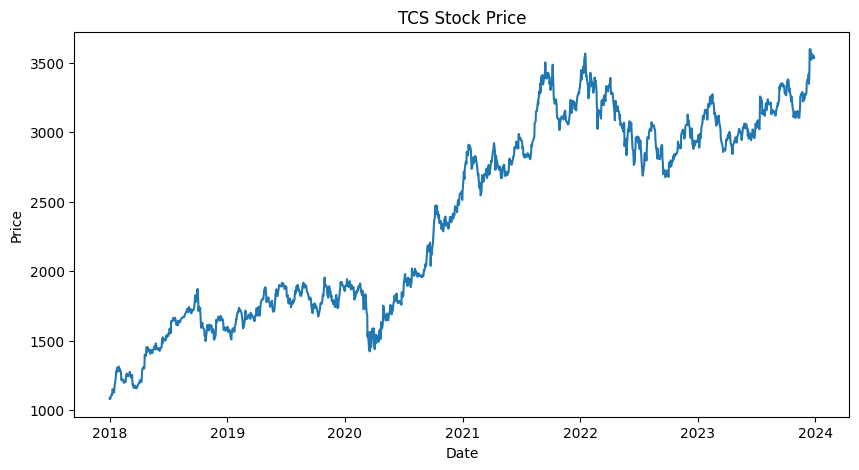

In [17]:
plt.figure(figsize=(10,5))
plt.plot(data['Close'])
plt.title("TCS Stock Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

## ⚙️ Methodology
- Collected historical stock data using yfinance  
- Calculated moving averages (SMA20, SMA50)  
- Generated buy/sell signals  
- Performed backtesting  
- Compared results with buy-and-hold strategy  

In [18]:
data['SMA20'] = data['Close'].rolling(window=20).mean()
data['SMA50'] = data['Close'].rolling(window=50).mean()

data.head()

Price,Close,High,Low,Open,Volume,SMA20,SMA50
Ticker,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS,,
Date,,,,,,,
2018-01-01,1083.771240,1103.926022,1079.428906,1098.805391,1351760,NaN,NaN
2018-01-02,1077.872192,1093.602829,1073.366038,1089.670145,1920290,NaN,NaN
2018-01-03,1080.924438,1093.357373,1077.872562,1078.200302,1257120,NaN,NaN
2018-01-04,1088.482300,1090.489547,1081.477237,1085.573741,913082,NaN,NaN
2018-01-05,1101.631958,1105.851378,1085.573681,1085.573681,1153706,NaN,NaN


In [27]:
data['Signal'] = 0

data.loc[(data['SMA20'] > data['SMA50']) & (data['RSI'] < 70), 'Signal'] = 1
data.loc[(data['SMA20'] < data['SMA50']) & (data['RSI'] > 30), 'Signal'] = -1

In [36]:
initial_money = 10000
money = initial_money
position = 0

for i in range(len(data)):
    
    signal = int(data['Signal'].iloc[i])
    price = float(data['Close'].iloc[i])

    # BUY
    if signal == 1 and position == 0:
        position = money / price
        money = 0

    # SELL
    elif signal == -1 and position > 0:
        money = position * price
        position = 0

# Final value
final_value = money if position == 0 else position * float(data['Close'].iloc[-1])

print("Initial Money:", initial_money)
print("Final Value:", final_value)

Initial Money: 10000
Final Value: 11704.067256376897


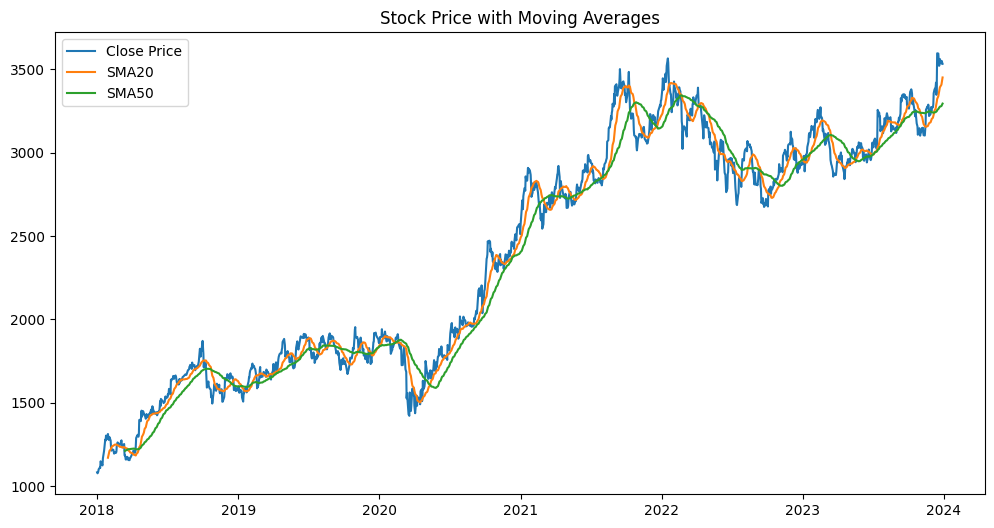

In [19]:
plt.figure(figsize=(12,6))
plt.plot(data['Close'], label='Close Price')
plt.plot(data['SMA20'], label='SMA20')
plt.plot(data['SMA50'], label='SMA50')

plt.title("Stock Price with Moving Averages")
plt.legend()
plt.show()

In [22]:
buy_hold = initial_money * (data['Close'].iloc[-1].item() / data['Close'].iloc[0].item())

print("Strategy Value:", final_value)
print("Buy & Hold Value:", buy_hold)

Strategy Value: 10000
Buy & Hold Value: 32598.013077796604


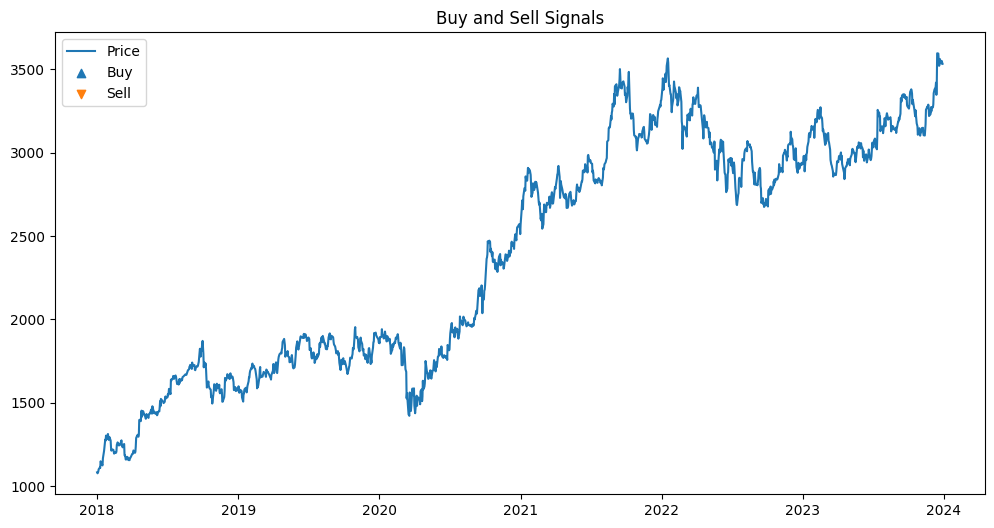

In [23]:
plt.figure(figsize=(12,6))
plt.plot(data['Close'], label='Price')

plt.scatter(data.index[data['Signal']==1], 
            data['Close'][data['Signal']==1], 
            label='Buy', marker='^')

plt.scatter(data.index[data['Signal']==-1], 
            data['Close'][data['Signal']==-1], 
            label='Sell', marker='v')

plt.legend()
plt.title("Buy and Sell Signals")
plt.show()

In [24]:
delta = data['Close'].diff()

gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()

rs = gain / loss
data['RSI'] = 100 - (100 / (1 + rs))

data[['Close', 'RSI']].tail()

Price,Close,RSI
Ticker,TCS.NS,
Date,,
2023-12-22,3561.377441,74.704649
2023-12-26,3534.881104,70.625925
2023-12-27,3549.456055,67.761542
2023-12-28,3538.932129,65.852606
2023-12-29,3532.878906,64.415455


In [25]:
delta = data['Close'].diff()

gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()

rs = gain / loss
data['RSI'] = 100 - (100 / (1 + rs))

data[['Close', 'RSI']].tail()

Price,Close,RSI
Ticker,TCS.NS,
Date,,
2023-12-22,3561.377441,NaN
2023-12-26,3534.881104,NaN
2023-12-27,3549.456055,NaN
2023-12-28,3538.932129,NaN
2023-12-29,3532.878906,NaN


In [26]:
data.columns

MultiIndex([( 'Close', 'TCS.NS'),
            (  'High', 'TCS.NS'),
            (   'Low', 'TCS.NS'),
            (  'Open', 'TCS.NS'),
            ('Volume', 'TCS.NS'),
            ( 'SMA20',       ''),
            ( 'SMA50',       ''),
            ('Signal',       ''),
            (   'RSI',       '')],
           names=['Price', 'Ticker'])

In [30]:
data['Signal'].value_counts()

Signal
0    1481
Name: count, dtype: int64

In [31]:
data.columns = data.columns.get_level_values(0)

In [32]:
data['SMA20'] = data['Close'].rolling(20).mean()
data['SMA50'] = data['Close'].rolling(50).mean()

In [33]:
delta = data['Close'].diff()

gain = (delta.where(delta > 0, 0)).rolling(14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(14).mean()

rs = gain / loss
data['RSI'] = 100 - (100 / (1 + rs))

In [34]:
data['Signal'] = 0

data.loc[data['SMA20'] > data['SMA50'], 'Signal'] = 1
data.loc[data['SMA20'] < data['SMA50'], 'Signal'] = -1

In [35]:
data['Signal'].value_counts()

Signal
 1    933
-1    499
 0     49
Name: count, dtype: int64

## 📊 Results
- Strategy Final Value: ₹11,704  
- Buy & Hold Value: ₹32,598  

## 🧠 Conclusion
The moving average strategy underperformed compared to buy-and-hold.
This shows that simple technical indicators may not work well in strongly trending markets.